# Business Impact Translation
This notebook translates raw forecasting accuracy metrics (like MAPE) into inventory-related financial terms (holding costs vs. stockout costs).

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Imports successful.")

Imports successful.


In [2]:
# Load predictions and targets
from src.evaluate import calculate_metrics
from src.inventory import calculate_inventory_impact

# Load the saved predictions from the modeling stage or main pipeline run
test_df = pd.read_csv('../outputs/results/test_predictions.csv', parse_dates=['date'])
y_test = test_df['sales'].values
baseline_preds = test_df['baseline_pred'].values
lgb_preds = test_df['model_pred'].values

print("Loaded predictions successfully.")

Loaded predictions successfully.


In [3]:
# Assume ₹150 unit cost, ₹250 selling price
UNIT_COST     = 150
SELLING_PRICE = 250

baseline_impact = calculate_inventory_impact(
    actual=y_test,
    predicted=baseline_preds,
    unit_cost=UNIT_COST,
    selling_price=SELLING_PRICE
)

model_impact = calculate_inventory_impact(
    actual=y_test,
    predicted=lgb_preds,
    unit_cost=UNIT_COST,
    selling_price=SELLING_PRICE
)

cost_saved = baseline_impact['total_cost'] - model_impact['total_cost']

print("=" * 65)
print(f"{'Metric':<35} {'Baseline':>12} {'LightGBM':>12}")
print("=" * 65)
print(f"{'Units Understocked (total)':<35} {baseline_impact['total_units_understocked']:>12,} {model_impact['total_units_understocked']:>12,}")
print(f"{'Units Overstocked (total)':<35} {baseline_impact['total_units_overstocked']:>12,} {model_impact['total_units_overstocked']:>12,}")
print(f"{'Stockout Cost (₹)':<35} {baseline_impact['stockout_cost']:>12,.0f} {model_impact['stockout_cost']:>12,.0f}")
print(f"{'Overstock Cost (₹)':<35} {baseline_impact['overstock_cost']:>12,.0f} {model_impact['overstock_cost']:>12,.0f}")
print(f"{'Total Cost (₹)':<35} {baseline_impact['total_cost']:>12,.0f} {model_impact['total_cost']:>12,.0f}")
print("=" * 65)
print(f"\n💰 Cost saved by using LightGBM vs Naive: ₹{cost_saved:,.0f}")

Metric                                  Baseline     LightGBM
Units Understocked (total)               111,658      108,016
Units Overstocked (total)                192,542      108,244
Stockout Cost (₹)                     41,871,750   40,506,362
Overstock Cost (₹)                        19,782       11,121
Total Cost (₹)                        41,891,532   40,517,483

💰 Cost saved by using LightGBM vs Naive: ₹1,374,049


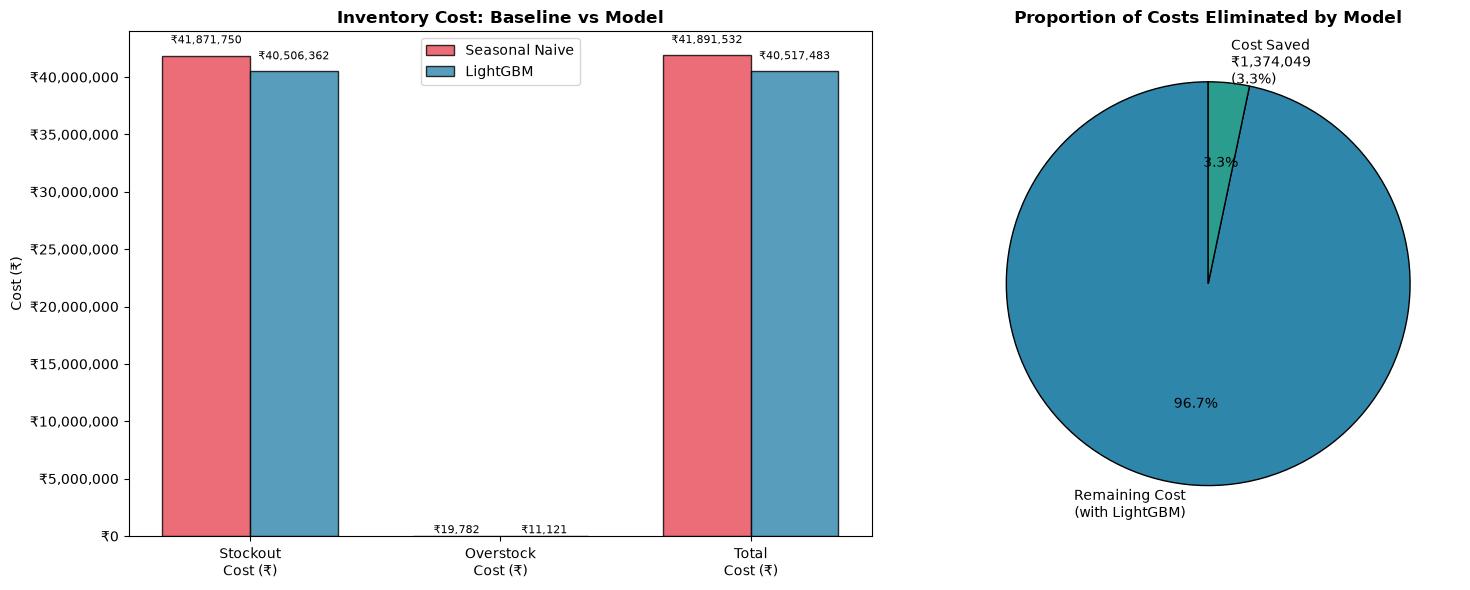

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

categories = ['Stockout\nCost (₹)', 'Overstock\nCost (₹)', 'Total\nCost (₹)']
baseline_vals = [baseline_impact['stockout_cost'],
                 baseline_impact['overstock_cost'],
                 baseline_impact['total_cost']]
model_vals = [model_impact['stockout_cost'],
              model_impact['overstock_cost'],
              model_impact['total_cost']]

x = np.arange(len(categories))
width = 0.35

bars1 = axes[0].bar(x - width/2, baseline_vals, width, label='Seasonal Naive',
                    color='#E84855', alpha=0.8, edgecolor='black')
bars2 = axes[0].bar(x + width/2, model_vals, width, label='LightGBM',
                    color='#2E86AB', alpha=0.8, edgecolor='black')

axes[0].set_title('Inventory Cost: Baseline vs Model', fontweight='bold')
axes[0].set_ylabel('Cost (₹)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                 f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                 f'₹{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

savings_pct = cost_saved / baseline_impact['total_cost'] * 100
axes[1].pie(
    [model_impact['total_cost'], cost_saved],
    labels=['Remaining Cost\n(with LightGBM)', f'Cost Saved\n₹{cost_saved:,.0f}\n({savings_pct:.1f}%)'],
    colors=['#2E86AB', '#2A9D8F'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)
axes[1].set_title('Proportion of Costs Eliminated by Model', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/plots/09_business_impact.png', dpi=150)
plt.show()